<a href="https://colab.research.google.com/github/piramid678-arch/FallGuard-AI/blob/master/%E1%84%90%E1%85%A1%E1%84%8B%E1%85%B5%E1%84%90%E1%85%A1%E1%84%82%E1%85%B5%E1%86%A8_1%E1%84%80%E1%85%A1%E1%86%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 타이타닉 — 누가 살아남았을까
### 강의에서 말한 그 예제를 직접 손으로

**나만의 인공지능 — 로컬AI의 정석** · 1강 실습 교재

---

강의에서 이렇게 말했습니다.

> "내가 10명 사람의 정보를 줄 거야. 이 사람은 남성이고, 몇 살이고… 근데 이 사람은 살았어.
> 그 다음 사람은… 생존을 하지 못했어. 이 데이터를 모두 줄 테니까
> **네가 잘 학습해서 예측할 수 있는 인공지능 모델을 만들어 봐.**"

오늘 그 말을 그대로 실행합니다. 세 걸음입니다.

| | 할 일 | 강의에서 |
|---|---|---|
| **1** | 두뇌를 **만든다** | 케라스 · 시퀀셜 · 도화지 모양 |
| **2** | 두뇌를 **가르친다** | 에포크 500번 · 로스(거리)를 줄인다 |
| **3** | 두뇌를 **열어본다** | w 와 b 가 무엇인지 확인 |

| | |
|---|---|
| 걸리는 시간 | 20분 |
| 드는 돈 | **0원** |
| 설치할 것 | **없습니다** |

---
# 1 · 승객 명단 올리기

1912년 타이타닉에 탔던 승객 **1,309명**의 실제 명단입니다.

아래 셀을 실행하면 **파일 고르기 창**이 뜹니다. `titanic.xls` 를 고르세요.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

# 파일이 이미 있으면 그대로 쓰고, 없으면 고르기 창을 띄웁니다
if os.path.exists('titanic.xls'):
    파일 = 'titanic.xls'
else:
    from google.colab import files
    파일 = list(files.upload())[0]

승객 = pd.read_csv(파일) if 파일.endswith('.csv') else pd.read_excel(파일)
print(f'{len(승객)}명의 명단을 읽었습니다')

Saving titanic (1).csv to titanic (1).csv
1309명의 명단을 읽었습니다


### 강의에서 말한 그 표

「이 사람은 남성이고, 몇 살이고, 살았어」— 열이 14개나 있지만 오늘은 **다섯 개만** 봅니다.

- **생존** 1 = 살았다, 0 = 죽었다
- **등급** 1 · 2 · 3 = 1등석 · 2등석 · 3등석
- **나이** NaN = 기록이 없음

In [3]:
표 = pd.DataFrame({
    '이름': 승객['name'],
    '성별': 승객['sex'],
    '나이': 승객['age'],
    '등급': 승객['pclass'],
    '생존': 승객['survived'],
    '키':승객['body'],
})

print(f'{len(표)}명 중 {표["생존"].sum()}명이 살았습니다')
표.head(10)                       # 강의처럼, 열 사람만 봅니다

1309명 중 500명이 살았습니다


,이름,성별,나이,등급,생존,키
0,"Allen, Miss. Elisabeth Walton",female,29.0000,1,1,NaN
1,"Allison, Master. Hudson Trevor",male,0.9167,1,1,NaN
2,"Allison, Miss. Helen Loraine",female,2.0000,1,0,NaN
3,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,0,135.0
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,0,NaN
5,"Anderson, Mr. Harry",male,48.0000,1,1,NaN
6,"Andrews, Miss. Kornelia Theodosia",female,63.0000,1,1,NaN
7,"Andrews, Mr. Thomas Jr",male,39.0000,1,0,NaN
8,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0000,1,1,NaN
9,"Artagaveytia, Mr. Ramon",male,71.0000,1,0,22.0


In [4]:
print(f"승객의 평균 나이: {표['나이'].mean():.2f}살")

승객의 평균 나이: 29.88살


/tmp/ipykernel_556/1209007.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=표, x='생존', y='나이', inner='quartile', palette='Set2')
/tmp/ipykernel_556/1209007.py:21: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_556/1209007.py:21: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_556/1209007.py:21: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_556/1209007.py:21: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_556/1209007.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykern

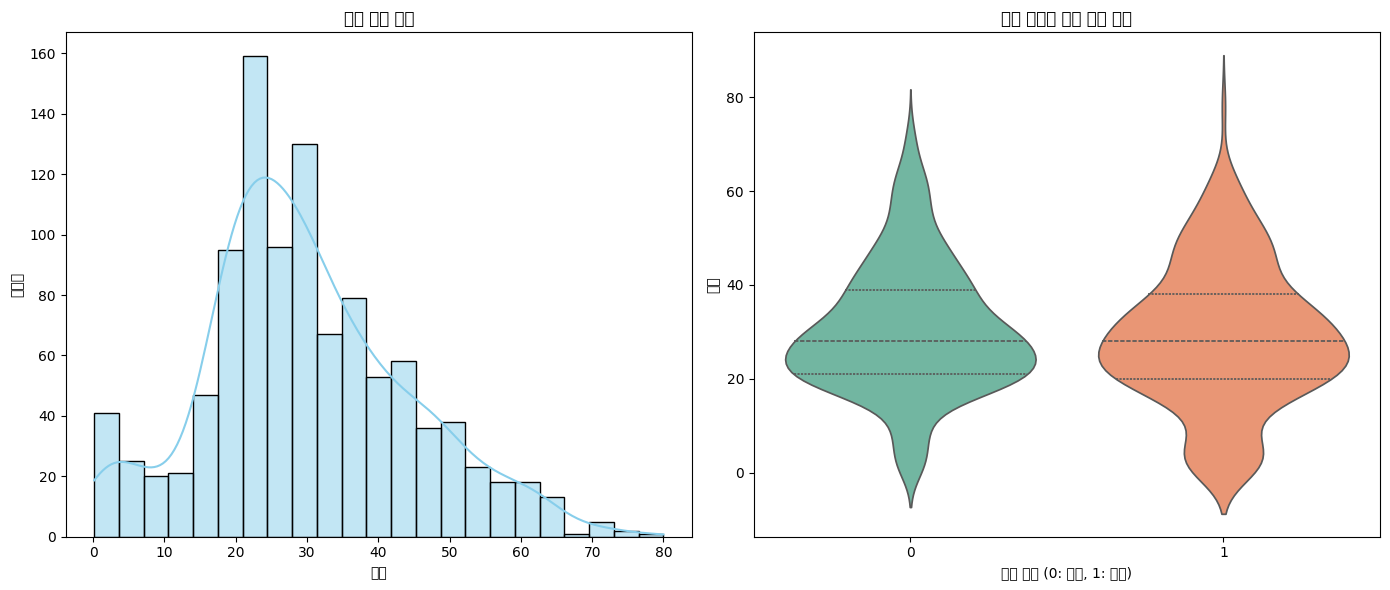

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 그래프 스타일 및 한글 폰트 설정 (이전 셀에서 설정된 폰트 사용)
plt.figure(figsize=(14, 6))

# 1. 나이 분포 (히스토그램)
plt.subplot(1, 2, 1)
sns.histplot(data=표, x='나이', kde=True, color='skyblue')
plt.title('승객 나이 분포')
plt.xlabel('나이')
plt.ylabel('인원수')

# 2. 생존 여부에 따른 나이 분포 (바이올린 플롯)
plt.subplot(1, 2, 2)
sns.violinplot(data=표, x='생존', y='나이', inner='quartile', palette='Set2')
plt.title('생존 여부에 따른 나이 분포')
plt.xlabel('생존 여부 (0: 사망, 1: 생존)')
plt.ylabel('나이')

plt.tight_layout()
plt.show()

In [6]:
# 한글 폰트(나눔글꼴) 설치 및 설정
!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 폰트를 matplotlib에 적용
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("한글 폰트 설정이 완료되었습니다. 아래 시각화 셀을 다시 실행해 보세요!")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

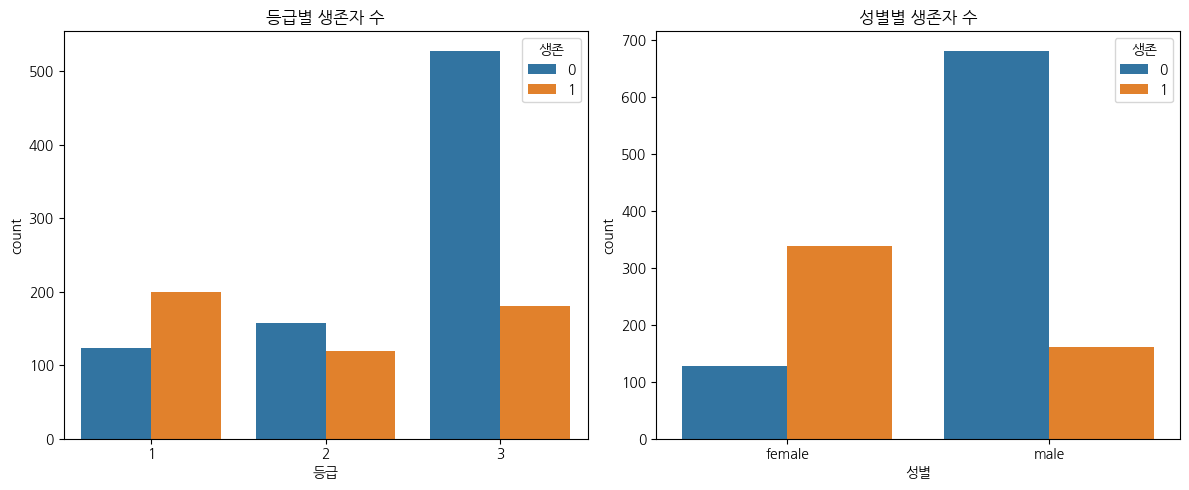

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 새로 설치된 폰트를 강제로 캐시에 추가
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 생존 여부에 따른 등급별, 성별 분포 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='등급', hue='생존', data=표)
plt.title('등급별 생존자 수')

plt.subplot(1, 2, 2)
sns.countplot(x='성별', hue='생존', data=표)
plt.title('성별별 생존자 수')

plt.tight_layout()
plt.show()

---
# 2 · 글자를 숫자로

강의에서 사진은 컴퓨터 안에서 **0~255 숫자**라고 했습니다. 글자도 마찬가지입니다.
두뇌에는 숫자만 들어갑니다. 그래서 두 가지를 손봅니다.

| 열 | 지금 | 바꾼 뒤 |
|---|---|---|
| 성별 | female / male | **1 / 0** |
| 나이 | 263명은 기록이 없음 (NaN) | 모르면 **28살** (가운데 나이) |
| 등급 | 1 · 2 · 3 | 이미 숫자. 그대로 |

In [8]:
표['성별'] = 표['성별'].map({'female': 1, 'male': 0})     # 여성 1, 남성 0
표['나이'] = 표['나이'].fillna(28)                          # 나이 모르면 28살

표.head(100)

,이름,성별,나이,등급,생존,키
0,"Allen, Miss. Elisabeth Walton",1,29.0000,1,1,NaN
1,"Allison, Master. Hudson Trevor",0,0.9167,1,1,NaN
2,"Allison, Miss. Helen Loraine",1,2.0000,1,0,NaN
3,"Allison, Mr. Hudson Joshua Creighton",0,30.0000,1,0,135.0
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,25.0000,1,0,NaN
...,...,...,...,...,...,...
95,"Dodge, Mrs. Washington (Ruth Vidaver)",1,54.0000,1,1,NaN
96,"Douglas, Mr. Walter Donald",0,50.0000,1,0,62.0
97,"Douglas, Mrs. Frederick Charles (Mary Helene B...",1,27.0000,1,1,NaN
98,"Douglas, Mrs. Walter Donald (Mahala Dutton)",1,48.0000,1,1,NaN


---
# 3 · 둘로 나누기

명단을 섞은 뒤 둘로 나눕니다.

```
  가르칠 명단  891명  →  정답(생존)을 보여 주고 배우게 한다
  시험 명단    418명  →  정답을 감추고, 배운 걸로 맞혀 보게 한다
```

시험 명단의 정답은 채점할 때까지 따로 감춰 둡니다.

In [9]:
표 = 표.sample(frac=1, random_state=3)     # 카드 섞듯 순서를 섞습니다 (3은 '매번 똑같이 섞어라'는 뜻)

가르칠명단 = 표[:891]
시험명단   = 표[891:].drop(columns='생존')     # 시험지에서는 정답을 뺍니다
시험정답   = 표[891:]['생존'].values          # 채점용. 두뇌에게는 안 보여 줍니다

print(f'가르칠 명단 {len(가르칠명단)}명 · 시험 명단 {len(시험명단)}명')

가르칠 명단 891명 · 시험 명단 418명


### 입력값과 결괏값

강의에서 「입력값과 결괏값만 주면서, 네가 알아서 함수를 만들어」라고 했습니다.

- **입력값** = 성별 · 나이 · 등급, 숫자 세 개
- **결괏값** = 생존, 1 또는 0

In [10]:
입력 = 가르칠명단[['성별', '나이', '등급']].values     # 891명 × 숫자 3개
정답 = 가르칠명단['생존'].values                       # 891명 × 살았나(1) 죽었나(0)

print('첫 사람  입력:', 입력[0], ' →  정답:', 정답[0])

첫 사람  입력: [ 0. 28.  3.]  →  정답: 0


---
# 4 · 두뇌 만들기

강의에서 본 함수입니다.

```
   y = w·x + b
```

지금은 x 가 셋(성별 · 나이 · 등급)이라 w 도 셋입니다. 그리고 끝에 한 가지가 붙습니다.

```
   성별 ──× w₁ ──┐
   나이 ──× w₂ ──┼──▶ ( + b ) ──▶ [ 0~1 로 누르기 ] ──▶ 살 확률
   등급 ──× w₃ ──┘
```

「0~1 로 누르기」는 결과가 몇이 나오든 **0과 1 사이의 확률**로 눌러 주는 장치입니다.
코드에서는 `sigmoid` 라고 씁니다. 이름만 알아 두세요.

| 부품 | 하는 일 |
|---|---|
| `Input(shape=(3,))` | 숫자 세 개가 들어옵니다 — 강의의 「도화지 모양」 |
| `Dense(1, activation='sigmoid')` | 계산 칸 하나. 곱하고 더한 뒤 0~1 로 누릅니다 |
| `loss='mse'` | 얼마나 틀렸는지 재는 자 — 강의의 「로스 = 거리」 |
| `optimizer` | 틀린 만큼 w 와 b 를 고치는 방법 |

w 와 b 는 지금 **아무 숫자**나 들어 있습니다. 가르치면서 찾아갈 겁니다.

In [12]:
생존두뇌 = keras.Sequential([
    keras.Input(shape=(3,)),                        # 성별, 나이, 등급
    keras.layers.Dense(1, activation='sigmoid'),    # 계산 칸 하나 → 살 확률
])
생존두뇌.compile(loss='mse', optimizer=keras.optimizers.Adam(0.003))

w, b = 생존두뇌.layers[0].get_weights()
print('가르치기 전  w :', w.flatten().round(3), '  b :', b.round(3))
print('아직 아무렇게나 들어 있는 숫자입니다.')

가르치기 전  w : [-0.365 -1.057  0.287]   b : [0.]
아직 아무렇게나 들어 있는 숫자입니다.


---
# 5 · 가르치기

강의에서 「에포크 500번」이라고 했습니다. 한 번에 500번을 시키는 대신
**100번마다 멈춰서** w 와 b 가 어떻게 바뀌는지 들여다봅니다. 맨 윗줄 0번은 가르치기 전입니다.
강의에서 「학습 중간중간 어떤 w 와 b 를 찾았는지 볼 수 있다」고 한 그 장면입니다.

In [13]:
틀린정도_기록 = []

for 번 in range(0, 1001, 100):
    if 번 > 0:
        학습 = 생존두뇌.fit(입력, 정답, epochs=100, verbose=0)   # 100번 가르치고
        틀린정도_기록 += 학습.history['loss']

    w, b = 생존두뇌.layers[0].get_weights()                    # 열어봅니다
    w성별, w나이, w등급 = w.flatten()                           # w 세 개를 풀어 놓습니다
    틀린정도 = 생존두뇌.evaluate(입력, 정답, verbose=0)         # 지금 얼마나 틀리나
    print(f'{번:3d}번 →  성별×{w성별:.2f}  나이×{w나이:.3f}  등급×{w등급:.2f}  + {b[0]:.2f}    틀린 정도 {틀린정도:.3f}')

  0번 →  성별×-0.37  나이×-1.057  등급×0.29  + 0.00    틀린 정도 0.372
100번 →  성별×2.43  나이×-0.021  등급×-0.83  + 0.66    틀린 정도 0.154
200번 →  성별×2.51  나이×-0.022  등급×-0.98  + 1.20    틀린 정도 0.151
300번 →  성별×2.55  나이×-0.029  등급×-1.05  + 1.49    틀린 정도 0.151
400번 →  성별×2.58  나이×-0.028  등급×-1.10  + 1.63    틀린 정도 0.151
500번 →  성별×2.58  나이×-0.031  등급×-1.13  + 1.72    틀린 정도 0.151
600번 →  성별×2.59  나이×-0.028  등급×-1.14  + 1.76    틀린 정도 0.151
700번 →  성별×2.61  나이×-0.028  등급×-1.14  + 1.79    틀린 정도 0.151
800번 →  성별×2.61  나이×-0.032  등급×-1.15  + 1.80    틀린 정도 0.151
900번 →  성별×2.61  나이×-0.031  등급×-1.15  + 1.81    틀린 정도 0.151
1000번 →  성별×2.61  나이×-0.031  등급×-1.16  + 1.82    틀린 정도 0.151


### 거리가 줄어드는 모습

강의에서 「선을 그려 보고, 거리가 머네, 다시 그려 보고, 줄어들었네」라고 했습니다.
그걸 500번 반복한 기록입니다.

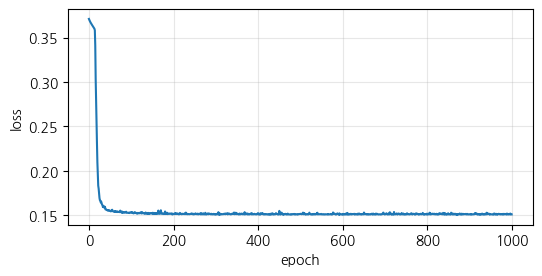

In [14]:
plt.figure(figsize=(6, 2.8))
plt.plot(틀린정도_기록)
plt.xlabel('epoch'); plt.ylabel('loss'); plt.grid(alpha=.3)
plt.show()

---
# 6 · 열어보기 — 기계가 찾아낸 함수

공식을 알려 준 적이 없습니다. 891명의 명단만 보고 두뇌가 **스스로** 정한 w 와 b 입니다.

In [15]:
w, b = 생존두뇌.layers[0].get_weights()
w성별, w나이, w등급 = w.flatten()

print('두뇌가 찾아낸 함수')
print(f'살 확률 = 누르기( {w성별:.2f}×성별  {w나이:.3f}×나이  {w등급:.2f}×등급  + {b[0]:.2f} )')

두뇌가 찾아낸 함수
살 확률 = 누르기( 2.61×성별  -0.031×나이  -1.16×등급  + 1.82 )


숫자 앞의 부호를 보세요.

| | 부호 | 뜻 |
|---|---|---|
| 성별 | **플러스** | 여성(1)일수록 살 확률이 올라간다 |
| 나이 | **마이너스** | 나이가 많을수록 살 확률이 내려간다 |
| 등급 | **마이너스** | 3등석으로 갈수록 살 확률이 내려간다 |

1912년 타이타닉의 구조 원칙은 **「여성과 아이 먼저」** 였습니다. 그리고 구명보트는 1등석 근처에 있었습니다.

두뇌에게 이 이야기를 해 준 사람은 아무도 없습니다. 숫자 891줄만 보고 찾아낸 것입니다.
강의에서 말한 **「사람이 아니라 기계가 함수를 만든다」** 가 바로 이것입니다.

---
# 7 · 시험 보기

시험 명단 418명에게 살 확률을 물어봅니다. 0.5 를 넘으면 「산다」로 적고, 감춰 둔 정답으로 채점합니다.

In [16]:
시험입력 = 시험명단[['성별', '나이', '등급']].values
살확률   = 생존두뇌.predict(시험입력, verbose=0).flatten()   # 418명의 살 확률
예측     = (살확률 >= 0.5).astype(int)                      # 0.5 넘으면 1(산다), 아니면 0

시험명단['살 확률(%)'] = (살확률 * 100).round().astype(int)   # 시험 명단에 두 열을 덧붙입니다
시험명단['예측'] = 예측
시험명단.head(10)

,이름,성별,나이,등급,키,살 확률(%),예측
1041,"Murdlin, Mr. Joseph",0,28.0,3,NaN,7,0
1074,"O'Connor, Mr. Patrick",0,28.0,3,NaN,7,0
812,"Fox, Mr. Patrick",0,28.0,3,NaN,7,0
905,"Jonsson, Mr. Carl",0,32.0,3,NaN,7,0
24,"Bird, Miss. Ellen",1,29.0,1,NaN,91,1
298,"Tucker, Mr. Gilbert Milligan Jr",0,31.0,1,NaN,42,0
556,"Sharp, Mr. Percival James R",0,27.0,2,NaN,21,0
575,"Turpin, Mrs. William John Robert (Dorothy Ann ...",1,27.0,2,NaN,78,1
18,"Bazzani, Miss. Albina",1,32.0,1,NaN,91,1
572,"Trout, Mrs. William H (Jessie L)",1,28.0,2,NaN,78,1


In [17]:
맞힌수 = (예측 == 시험정답).sum()
정확도 = 맞힌수 / len(시험정답) * 100

print(f'시험 명단 {len(시험정답)}명 중 {맞힌수}명을 맞혔습니다  →  정확도 {정확도:.1f}%')
print()
print(f'아무것도 안 배우고 「전부 죽었다」고 찍으면  {(시험정답 == 0).mean() * 100:.1f}%')

시험 명단 418명 중 330명을 맞혔습니다  →  정확도 78.9%

아무것도 안 배우고 「전부 죽었다」고 찍으면  62.2%


---
# 8 · 내가 탔다면?

강의에서 「사랑해를 넣으면 I love you 가 나온다」고 했습니다.
우리 두뇌는 **성별 · 나이 · 등급을 넣으면 살 확률**이 나옵니다. 아무나 넣어 보세요.

In [18]:
사람들 = [
    ['제이', 0, 38, 2],      # 여성, 17살, 1등석
    ['잭',   0, 20, 3],      # 남성, 20살, 3등석
    ['나',   0, 35, 2],      # ← 여기를 내 정보로 바꿔 보세요
]

for 이름, 성별, 나이, 등급 in 사람들:
    확률 = 생존두뇌.predict(np.array([[성별, 나이, 등급]]), verbose=0)[0][0]
    print(f'{이름:4s}  성별 {성별} · 나이 {나이:2d} · 등급 {등급}  →  살 확률 {확률 * 100:.0f}%')

제이    성별 0 · 나이 38 · 등급 2  →  살 확률 16%
잭     성별 0 · 나이 20 · 등급 3  →  살 확률 9%
나     성별 0 · 나이 35 · 등급 2  →  살 확률 17%


### 함수를 그래프로

강의에서 y = wx + b 를 그래프로 그렸습니다. 우리 함수도 그려 봅니다.
나이를 0살부터 80살까지 바꿔 가며 살 확률을 찍은 것입니다.

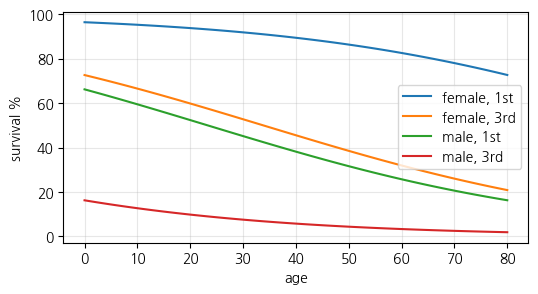

In [ ]:
나이들 = np.arange(0, 81)

plt.figure(figsize=(6, 3))
for 성별, 등급, 라벨 in [(1, 1, 'female, 1st'), (1, 3, 'female, 3rd'),
                          (0, 1, 'male, 1st'),   (0, 3, 'male, 3rd')]:
    입력들 = np.array([[성별, 나이, 등급] for 나이 in 나이들])
    plt.plot(나이들, 생존두뇌.predict(입력들, verbose=0).flatten() * 100, label=라벨)
plt.xlabel('age'); plt.ylabel('survival %'); plt.legend(); plt.grid(alpha=.3)
plt.show()

---
# 직접 해보기

**① 더 오래 가르쳐 보세요**
5번 셀의 `range(0, 501, 100)` 을 `range(0, 2001, 100)` 으로. 2,000번 가르치면 w 는 어디서 멈출까요?

**② 나이를 빼 보세요**
`['성별', '나이', '등급']` 이 나오는 두 곳에서 `'나이'` 를 지우고, `shape=(3,)` 을 `shape=(2,)` 로.
「내가 탔다면」과 그래프 셀의 숫자도 두 개로 줄여야 합니다. 정확도가 얼마나 떨어질까요?

**③ 요금도 넣어 보세요**
표를 만드는 곳에 `'요금': 승객['fare'],` 한 줄을 넣고, 기록이 없는 한 사람은 `표['요금'] = 표['요금'].fillna(14)` 로 채우세요.
그 다음 ②와 반대로 `'요금'` 을 두 곳에 넣고 `shape=(4,)` 로. 정확도가 오를까요?

**④ 두뇌를 깊게 만들어 보세요**
`Dense(1, ...)` 줄 바로 앞에 `keras.layers.Dense(8, activation='relu'),` 한 줄을 끼워 넣으세요.
층이 두 개가 됩니다. 이게 「딥」러닝의 시작입니다. 단, 층이 둘이면 6번 셀의 `layers[0]` 은 첫 번째 층만 보여 줍니다.

---

## 막히면

| 증상 | 이유와 해결 |
|---|---|
| `NameError` | 위 셀을 건너뛰었습니다. 맨 위부터 순서대로 실행 |
| 파일 고르기 창이 안 뜸 | 왼쪽 📁 아이콘 → 업로드 → titanic.xls 를 올린 뒤 1번 셀 다시 실행 |
| xls 파일을 못 읽는다고 나옴 | titanic.xls 대신 titanic.csv 를 올리세요. 내용은 같습니다 |
| 실행할 때마다 숫자가 조금 다름 | 정상입니다. 가르치기 전 w 와 b 가 매번 무작위라서 그렇습니다 |
| 정확도가 78% 근처에서 안 오름 | 정상입니다. 성별 · 나이 · 등급 셋만으로는 여기가 한계입니다 |

---

## 오늘 확인한 것

| | 강의에서 | 직접 해 본 것 |
|---|---|---|
| 두뇌를 만든다 | 케라스 시퀀셜 · 도화지 모양 | `Input(shape=(3,))` 과 `Dense(1)` |
| 두뇌를 가르친다 | 에포크 500 · 로스를 줄인다 | 100번마다 w 와 b 가 움직이고, 거리가 줄어드는 걸 봤습니다 |
| 두뇌를 열어본다 | get_weights | 「여성 +, 나이 −, 등급 −」— 여성과 아이 먼저를 기계가 스스로 찾았습니다 |

공식을 준 적이 없습니다. **입력값과 결괏값만 주고, 함수는 기계가 만들었습니다.**
챗GPT도 같은 방식입니다. 층이 더 깊고, 읽은 것이 더 많을 뿐입니다.

*AI CITY BUILDERS · www.aicitybuilders.com*